# SECCIÓN 1 — Introducción al Proyecto Multiagente

## Descripción General

En este proyecto desarrollaremos un sistema multiagente aplicado al problema de abandono de clientes (Customer Churn) utilizando el dataset **Telco Customer Churn**.

El objetivo principal es construir tres agentes especializados que trabajen de forma secuencial para transformar los datos originales en conocimiento útil y posteriormente comunicar los resultados mediante técnicas de Inteligencia Artificial Generativa.

---

## Dataset Utilizado

Telco Customer Churn

Cantidad aproximada de registros:

- 7043 clientes

Variable objetivo:

- Churn

La variable "Churn" indica si un cliente abandonó o no el servicio.

---

## Arquitectura del Sistema

Dataset CSV

↓

AGENTE 1 — NORMALIZADOR

↓

AGENTE 2 — ENTRENADOR

↓

AGENTE 3 — COMUNICADOR

---

## Agente 1 — Normalizador

Responsabilidades:

- Exploración del dataset
- Detección de valores faltantes
- Corrección de tipos de datos
- Limpieza de información
- Codificación de variables categóricas
- Escalado de variables numéricas

Salida:

Dataset preparado para Machine Learning.

---

## Agente 2 — Entrenador

Responsabilidades:

- Separación de variables predictoras y variable objetivo
- División Train/Test
- Entrenamiento del modelo
- Evaluación del rendimiento
- Obtención de métricas

Salida:

Modelo entrenado y métricas de desempeño.

---

## Agente 3 — Comunicador

Responsabilidades:

- Construcción del corpus documental
- Generación de embeddings
- Almacenamiento vectorial
- Recuperación de información mediante RAG
- Generación de respuestas utilizando Mistral Small

Tecnologías:

- LangChain
- FAISS
- Embeddings
- Mistral Small

Salida:

Sistema capaz de responder preguntas sobre:

- Dataset
- Modelo entrenado
- Métricas obtenidas
- Variables más importantes

---

## Objetivos de Aprendizaje

Durante este proyecto aplicaremos conceptos estudiados previamente:

- Pandas
- Normalización de datasets
- Machine Learning
- Agentes
- Embeddings
- FAISS
- LangChain
- RAG
- Mistral AI

El resultado final será un sistema multiagente capaz de transformar datos en conocimiento y comunicar los resultados mediante Inteligencia Artificial Generativa.

# SECCIÓN 2 — Configuración del Entorno

En esta sección instalaremos las librerías necesarias para el desarrollo de los tres agentes del proyecto.

Las librerías seleccionadas permitirán realizar:

- Procesamiento de datos
- Machine Learning
- Construcción del sistema RAG
- Integración con Mistral AI

In [1]:
# ==========================================
# SECCIÓN 2 - Instalación de librerías
# ==========================================

# ----------------------------
# Procesamiento de datos
# ----------------------------
!pip install -q pandas numpy

# ----------------------------
# Visualización
# ----------------------------
!pip install -q matplotlib seaborn

# ----------------------------
# Machine Learning
# ----------------------------
!pip install -q scikit-learn

# ----------------------------
# Mistral AI
# SDK oficial
# ----------------------------
!pip install -q mistralai

# ----------------------------
# LangChain
# ----------------------------
!pip install -q langchain
!pip install -q langchain-community
!pip install -q langchain-core

# ----------------------------
# Vector Database
# ----------------------------
!pip install -q faiss-cpu

# ----------------------------
# Utilidades
# ----------------------------
!pip install -q tqdm

print("✅ Librerías instaladas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ==========================================
# Importaciones principales
# ==========================================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Utilidades
from tqdm import tqdm

print("✅ Importaciones realizadas correctamente")

✅ Importaciones realizadas correctamente


# SECCIÓN 3 — Carga del Dataset

En esta sección cargaremos el dataset Telco Customer Churn y verificaremos su estructura inicial antes de comenzar el proceso de normalización.

In [3]:
# ==========================================
# SECCIÓN 3 - Carga del dataset
# ==========================================

from google.colab import files

# Solicitar al usuario seleccionar el archivo CSV
uploaded = files.upload()

# Obtener automáticamente el nombre del archivo cargado
archivo = next(iter(uploaded))

# Cargar el dataset en un DataFrame
df = pd.read_csv(archivo)

print("✅ Dataset cargado correctamente")
print(f"Archivo cargado: {archivo}")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
✅ Dataset cargado correctamente
Archivo cargado: WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
# ==========================================
# Primer vistazo al dataset
# ==========================================

# Mostrar las primeras filas del dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ==========================================
# Dimensiones del dataset
# ==========================================

# Obtener número de filas y columnas
filas, columnas = df.shape

print(f"Número de registros: {filas:,}")
print(f"Número de variables: {columnas}")

Número de registros: 7,043
Número de variables: 21


In [6]:
# ==========================================
# Información general del dataset
# ==========================================

# Mostrar tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# ==========================================
# Estadísticas descriptivas
# ==========================================

# Resumen estadístico de variables numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# SECCIÓN 4 — Exploración Inicial del Dataset

En esta sección identificaremos las variables numéricas, categóricas y la variable objetivo del problema, además de analizar la distribución de las clases.

In [8]:
# ==========================================
# SECCIÓN 4 - Variables del dataset
# ==========================================

# Mostrar nombres de las columnas
print("Columnas del dataset:\n")

for columna in df.columns:
    print(columna)

Columnas del dataset:

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [9]:
# ==========================================
# Identificación de variables numéricas
# y categóricas
# ==========================================

# Seleccionar columnas numéricas
variables_numericas = df.select_dtypes(include=np.number).columns.tolist()

# Seleccionar columnas categóricas
variables_categoricas = df.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Variables categóricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [10]:
# ==========================================
# Variable objetivo
# ==========================================

variable_objetivo = "Churn"

print("Variable objetivo:", variable_objetivo)

# Distribución de clases
df[variable_objetivo].value_counts()

Variable objetivo: Churn


,count
Churn,
No,5174
Yes,1869


In [11]:
# ==========================================
# Distribución porcentual de las clases
# ==========================================

# Obtener porcentaje de cada clase
porcentajes = (
    df[variable_objetivo]
    .value_counts(normalize=True)
    * 100
)

print("Distribución porcentual de la variable objetivo:\n")
print(porcentajes)

Distribución porcentual de la variable objetivo:

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


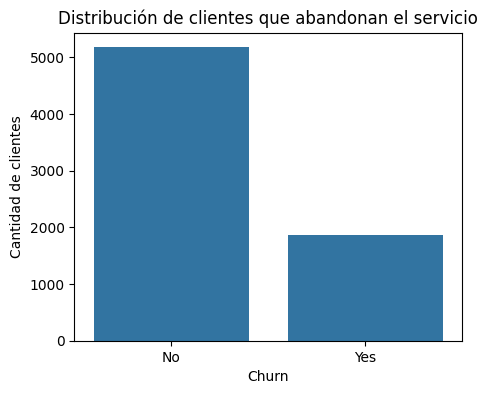

In [12]:
# ==========================================
# Visualización de la variable objetivo
# ==========================================

plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribución de clientes que abandonan el servicio")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

In [13]:
# ==========================================
# Valores únicos por columna
# ==========================================

# Analizar cardinalidad de cada variable
for columna in df.columns:

    print(f"\n{columna}")
    print("-"*40)

    print(
        df[columna]
        .nunique()
    )


customerID
----------------------------------------
7043

gender
----------------------------------------
2

SeniorCitizen
----------------------------------------
2

Partner
----------------------------------------
2

Dependents
----------------------------------------
2

tenure
----------------------------------------
73

PhoneService
----------------------------------------
2

MultipleLines
----------------------------------------
3

InternetService
----------------------------------------
3

OnlineSecurity
----------------------------------------
3

OnlineBackup
----------------------------------------
3

DeviceProtection
----------------------------------------
3

TechSupport
----------------------------------------
3

StreamingTV
----------------------------------------
3

StreamingMovies
----------------------------------------
3

Contract
----------------------------------------
3

PaperlessBilling
----------------------------------------
2

PaymentMethod
---------------------

# SECCIÓN 5 — Calidad de los Datos

En esta sección analizaremos la calidad del dataset para identificar valores faltantes, registros duplicados y posibles inconsistencias antes de iniciar el proceso de limpieza.

In [14]:
# ==========================================
# SECCIÓN 5 - Valores faltantes
# ==========================================

# Contar valores nulos por columna
valores_nulos = df.isnull().sum()

print("Valores nulos por variable:\n")
print(valores_nulos)

Valores nulos por variable:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
# ==========================================
# Porcentaje de valores faltantes
# ==========================================

# Calcular porcentaje de valores faltantes
porcentaje_nulos = (
    df.isnull().sum()
    / len(df)
    * 100
)

print("Porcentaje de valores faltantes:\n")
print(porcentaje_nulos)

Porcentaje de valores faltantes:

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [16]:
# ==========================================
# Registros duplicados
# ==========================================

# Contar filas duplicadas
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


In [17]:
# ==========================================
# Verificar tipos de datos
# ==========================================

print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [18]:
# ==========================================
# Analizar la columna TotalCharges
# ==========================================

# Mostrar tipo actual
print("Tipo actual de TotalCharges:")
print(df["TotalCharges"].dtype)

# Mostrar algunos valores
print("\nPrimeros valores:")
print(df["TotalCharges"].head())

Tipo actual de TotalCharges:
object

Primeros valores:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object


In [19]:
# ==========================================
# Buscar posibles cadenas vacías
# ==========================================

# Contar registros que contienen espacios vacíos
espacios_vacios = (df["TotalCharges"] == " ").sum()

print(f"Cantidad de espacios vacíos en TotalCharges: {espacios_vacios}")

Cantidad de espacios vacíos en TotalCharges: 11


In [20]:
# ==========================================
# Resumen de calidad del dataset
# ==========================================

print("=" * 50)
print("RESUMEN DE CALIDAD DEL DATASET")
print("=" * 50)

print(f"Registros totales: {len(df)}")
print(f"Registros duplicados: {df.duplicated().sum()}")

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nTipo de dato de TotalCharges:")
print(df["TotalCharges"].dtype)

RESUMEN DE CALIDAD DEL DATASET
Registros totales: 7043
Registros duplicados: 0

Valores faltantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Tipo de dato de TotalCharges:
object


# SECCIÓN 6 — Limpieza y Corrección de Datos

En esta sección corregiremos las inconsistencias detectadas durante el análisis de calidad del dataset, dejando los datos preparados para las siguientes etapas del proceso.

In [21]:
# ==========================================
# SECCIÓN 6 - Limpieza de TotalCharges
# ==========================================

# Reemplazar cadenas vacías por NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convertir la columna a tipo numérico
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Tipo de dato actualizado:")
print(df["TotalCharges"].dtype)

Tipo de dato actualizado:
float64


In [22]:
# ==========================================
# Valores faltantes después de la conversión
# ==========================================

print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [23]:
# ==========================================
# Imputación de valores faltantes
# ==========================================

# Reemplazar los NaN por la mediana
mediana_total_charges = df["TotalCharges"].median()

df["TotalCharges"] = df["TotalCharges"].fillna(
    mediana_total_charges
)

print("Valores faltantes restantes:")
print(df.isnull().sum())

Valores faltantes restantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [24]:
# ==========================================
# Eliminación de registros duplicados
# ==========================================

# Número de registros antes
filas_antes = len(df)

# Eliminar duplicados
df = df.drop_duplicates()

# Número de registros después
filas_despues = len(df)

print(f"Registros antes: {filas_antes}")
print(f"Registros después: {filas_despues}")
print(f"Duplicados eliminados: {filas_antes - filas_despues}")

Registros antes: 7043
Registros después: 7043
Duplicados eliminados: 0


In [25]:
# ==========================================
# Verificación final
# ==========================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
# ==========================================
# Resumen del proceso de limpieza
# ==========================================

print("=" * 50)
print("RESUMEN DE LIMPIEZA")
print("=" * 50)

print(f"Cantidad final de registros: {len(df)}")

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nTipos de datos:")
print(df.dtypes)

RESUMEN DE LIMPIEZA
Cantidad final de registros: 7043

Valores faltantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract      

# SECCIÓN 7 — Codificación de Variables Categóricas

En esta sección convertiremos las variables categóricas en variables numéricas para que puedan ser utilizadas por los algoritmos de Machine Learning.

In [27]:
# ==========================================
# SECCIÓN 7 - Codificación de la variable objetivo
# ==========================================

# Visualizar las clases presentes
print("Clases de la variable objetivo:")
print(df["Churn"].unique())

# Convertir:
# No  -> 0
# Yes -> 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("\nDistribución después de la codificación:")
print(df["Churn"].value_counts())

Clases de la variable objetivo:
['No' 'Yes']

Distribución después de la codificación:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [28]:
# ==========================================
# Variables categóricas predictoras
# ==========================================

# Obtener todas las columnas categóricas
variables_categoricas = df.select_dtypes(
    include="object"
).columns.tolist()

print("Variables categóricas a codificar:\n")

for variable in variables_categoricas:
    print(variable)

Variables categóricas a codificar:

customerID
gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod


In [29]:
# ==========================================
# Eliminar identificadores
# ==========================================

# customerID es únicamente un identificador
# y no aporta información útil al modelo

df = df.drop(columns=["customerID"])

print("customerID eliminado correctamente.")

customerID eliminado correctamente.


In [30]:
# ==========================================
# One-Hot Encoding
# ==========================================

# Convertir variables categóricas en variables binarias
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

print("Codificación realizada correctamente.")

Codificación realizada correctamente.


In [31]:
# ==========================================
# Verificar dimensiones del nuevo dataset
# ==========================================

filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de variables después del encoding: {columnas}")

Número de registros: 7043
Número de variables después del encoding: 31


In [32]:
# ==========================================
# Verificar que ya no existan variables object
# ==========================================

variables_object = df.select_dtypes(
    include="object"
).columns.tolist()

print("Columnas tipo object restantes:")
print(variables_object)

Columnas tipo object restantes:
[]


# SECCIÓN 8 — Preparación para Machine Learning

En esta sección prepararemos los datos para el entrenamiento del modelo.

Se separarán las variables predictoras y la variable objetivo antes de realizar la división en conjuntos de entrenamiento y prueba.

In [33]:
# ==========================================
# SECCIÓN 8 - Preparación para Machine Learning
# ==========================================

# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df.drop(columns=["Churn"])

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7043, 30)
Dimensiones de y: (7043,)


In [34]:
# ==========================================
# Verificar la variable objetivo
# ==========================================

print("Distribución de clases:")

print(y.value_counts())

print("\nDistribución porcentual:")

print(
    y.value_counts(normalize=True) * 100
)

Distribución de clases:
Churn
0    5174
1    1869
Name: count, dtype: int64

Distribución porcentual:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [35]:
# ==========================================
# Primer vistazo a las variables predictoras
# ==========================================

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [36]:
# ==========================================
# Confirmar que no existen valores faltantes
# ==========================================

print("Valores faltantes en X:")

print(
    X.isnull().sum().sum()
)

print("\nValores faltantes en y:")

print(
    y.isnull().sum()
)

Valores faltantes en X:
0

Valores faltantes en y:
0


# SECCIÓN 9 — División Train/Test

En esta sección dividiremos el dataset en conjuntos de entrenamiento y prueba utilizando una estrategia estratificada para preservar la distribución de la variable objetivo.

In [37]:
# ==========================================
# SECCIÓN 9 - División Train/Test
# ==========================================

# Dividir el dataset en entrenamiento y prueba
# 80% entrenamiento
# 20% prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("División realizada correctamente.")

División realizada correctamente.


In [38]:
# ==========================================
# Dimensiones de los conjuntos
# ==========================================

print("Conjunto de entrenamiento:")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nConjunto de prueba:")

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Conjunto de entrenamiento:
X_train: (5634, 30)
y_train: (5634,)

Conjunto de prueba:
X_test: (1409, 30)
y_test: (1409,)


In [39]:
# ==========================================
# Verificar distribución de clases
# ==========================================

print("Distribución en y_train:\n")

print(
    y_train.value_counts(normalize=True) * 100
)

print("\nDistribución en y_test:\n")

print(
    y_test.value_counts(normalize=True) * 100
)

Distribución en y_train:

Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribución en y_test:

Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [40]:
# ==========================================
# Comparación de proporciones
# ==========================================

print("Distribución original:")

print(
    y.value_counts(normalize=True) * 100
)

print("\nDistribución entrenamiento:")

print(
    y_train.value_counts(normalize=True) * 100
)

print("\nDistribución prueba:")

print(
    y_test.value_counts(normalize=True) * 100
)

Distribución original:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Distribución entrenamiento:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribución prueba:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


## SECCIÓN 8 — Guardado del dataset normalizado

Exportamos el dataset limpio y normalizado para que los siguientes agentes
(Transformer Classifier, RAG Builder) puedan consumirlo directamente.

In [ ]:
# Guardamos el dataset normalizado como CSV
output_path = "ag_news_normalizado.csv"

df_train.to_csv(output_path, index=False, encoding="utf-8")

# Verificamos que se haya guardado correctamente
saved = pd.read_csv(output_path)
print(f"Dataset normalizado guardado exitosamente:")
print(f"  - Archivo: {output_path}")
print(f"  - Filas: {len(saved):,}")
print(f"  - Columnas: {len(saved.columns)}")
print(f"  - Columnas: {list(saved.columns)}")

In [ ]:
# Descargamos el archivo para usarlo localmente o en otros agentes
from google.colab import files
files.download(output_path)

## Sección 9 — Resumen y resultados del Agente 1

### ¿Qué hizo el Agente 1 - Data Curator?

1. **Cargó** el dataset AG News (120.000 noticias de entrenamiento)
2. **Analizó** la estructura, tipos, nulos, duplicados y distribución
3. **Normalizó** mediante un agente LangChain + Mistral:
   - Texto en minúsculas y limpio
   - Categorías mapeadas a nombres legibles
   - Métricas de texto calculadas (text_length, word_count)
   - Duplicados eliminados
4. **Exportó** el dataset listo para el Agente 2 (Transformer Classifier)

### Dataset final
| Atributo | Valor |
|---|---|
| Filas | 120.000 |
| Columnas | 5 (text, label, category_name, text_length, word_count) |
| Categorías | Mundo, Deportes, Negocios, Ciencia/Tecnología |
| Archivo | `ag_news_normalizado.csv` |

### Próximos pasos (Agentes 2-4)
- **Agente 2 - Transformer Classifier:** Fine-tuning de DistilBERT para clasificar noticias
- **Agente 3 - RAG Builder:** Base vectorial con ChromaDB para búsqueda semántica
- **Agente 4 - Interactive Assistant:** Chat que combina clasificación + RAG